loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package oc...
    loading package chd...
    loading package ic...
    loading package npf...
  loading solution package flow...


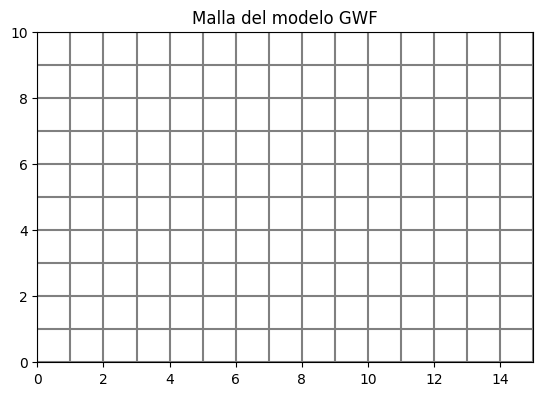

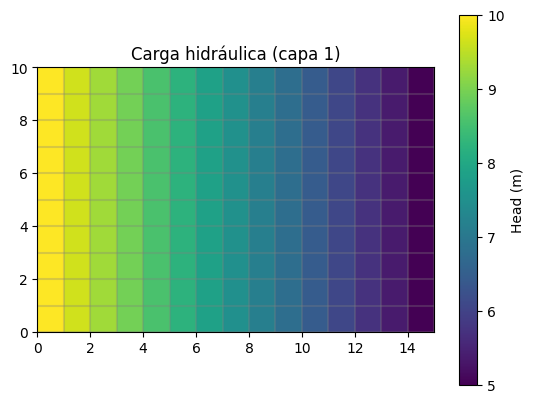

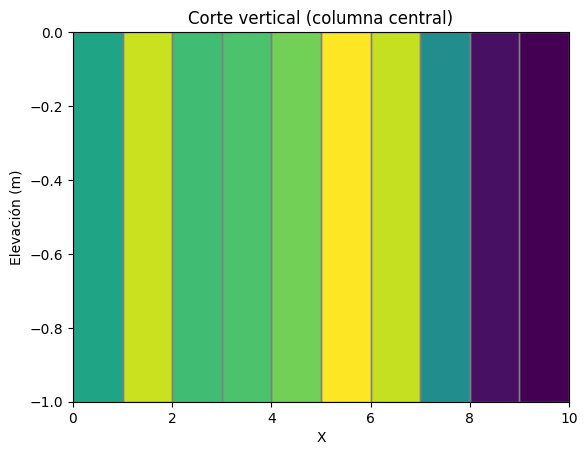

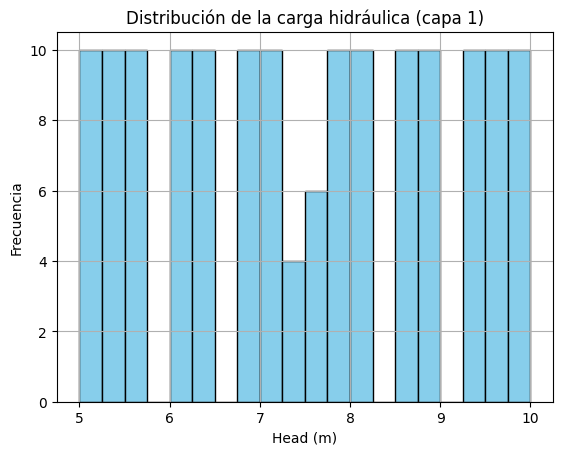

In [4]:
import flopy
import matplotlib.pyplot as plt
import numpy as np
from flopy.plot import PlotMapView, PlotCrossSection

# Cargar simulación existente
sim = flopy.mf6.MFSimulation.load(sim_ws="sandbox2")
gwf = sim.get_model("flow")

# Obtener heads
headfile = gwf.output.head()
head = headfile.get_data(totim=headfile.get_times()[-1])  # Último paso de tiempo

# 1. Malla del modelo
fig, ax = plt.subplots()
mapview = PlotMapView(model=gwf, ax=ax)
mapview.plot_grid()
plt.title("Malla del modelo GWF")
plt.gca().set_aspect('equal')
plt.show()

# 2. Contornos de carga hidráulica en planta
fig, ax = plt.subplots()
mapview = PlotMapView(model=gwf, ax=ax)
cb = mapview.plot_array(head[0], cmap="viridis", vmin=np.nanmin(head), vmax=np.nanmax(head))
mapview.plot_grid(alpha=0.3)
plt.title("Carga hidráulica (capa 1)")
plt.colorbar(cb, label="Head (m)")
plt.gca().set_aspect('equal')
plt.show()

# 3. Corte vertical con carga hidráulica
fig, ax = plt.subplots()
xsec = PlotCrossSection(model=gwf, line={"column": gwf.modelgrid.ncol // 2}, ax=ax)
xsec.plot_array(head, cmap="viridis")
xsec.plot_grid()
plt.title("Corte vertical (columna central)")
plt.xlabel("X")
plt.ylabel("Elevación (m)")
#plt.colorbar(label="Head (m)")
plt.show()

# 4. Diferencia de carga entre dos capas (por ejemplo, capa 1 y 2)
if gwf.modelgrid.nlay > 1:
    dh = head[0] - head[1]
    fig, ax = plt.subplots()
    mapview = PlotMapView(model=gwf, ax=ax)
    mapview.plot_array(dh, cmap="coolwarm", vmin=-np.nanmax(abs(dh)), vmax=np.nanmax(abs(dh)))
    mapview.plot_grid(alpha=0.3)
    plt.title("Diferencia de carga: capa 1 - capa 2")
#    plt.colorbar(label="Δ Head (m)")
    plt.gca().set_aspect('equal')
    plt.show()

# 5. Histograma de la carga hidráulica
fig, ax = plt.subplots()
hval = head[0].flatten()
hval = hval[np.isfinite(hval)]
plt.hist(hval, bins=20, color="skyblue", edgecolor="k")
plt.title("Distribución de la carga hidráulica (capa 1)")
plt.xlabel("Head (m)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

In [16]:
import numpy as np


In [1]:
def parVar(*args, **kwargs):
    print('args es una tupla : ', args)
    print('kwargs es un diccionario: ', kwargs)

In [2]:
parVar('one', 'two','three', 'four', 
       a=4,  x=1, y=2, z=3, w=[1,2,2])

args es una tupla :  ('one', 'two', 'three', 'four')
kwargs es un diccionario:  {'a': 4, 'x': 1, 'y': 2, 'z': 3, 'w': [1, 2, 2]}


In [3]:
parVar(1, 2, 3, 
       w=8, y='cadena')

args es una tupla :  (1, 2, 3)
kwargs es un diccionario:  {'w': 8, 'y': 'cadena'}


In [4]:
# Desempacar los parámetros posicionales y usarlos
def parVarPos(*args):
    for i in args:
        print(i)

In [5]:
parVarPos(1, 2, 'a', [1,2,3])

1
2
a
[1, 2, 3]


In [6]:
parVarPos(3.1416, 'b', 5+3j)

3.1416
b
(5+3j)


In [20]:
def otra_ver(diccionario):
    for k, v in diccionario.items():
        print(k, v)

In [26]:
parametros = {
    "uno": {'a':1, 'b':2},
    "dos": {'x':3.14, 'y':5.43, 'z':0.0},
    "tres": {}
}
otra_ver(parametros)

uno {'a': 1, 'b': 2}
dos {'x': 3.14, 'y': 5.43, 'z': 0.0}
tres {}


In [7]:
# Desempacar los parámetros con nombre y usarlos
def parVarKey(**kwargs):
    for key, val in kwargs.items():
        print(f" {key} : {val}")

In [8]:
parVarKey(nombre = 'Luis', 
          apellido = 'de la Cruz', 
          edad = 15, 
          peso = 80.5 )

 nombre : Luis
 apellido : de la Cruz
 edad : 15
 peso : 80.5


In [9]:
parVarKey(nombre = 'Luis', 
          apellido='de la Cruz', 
          estudios='primaria', 
          edad=15, 
          peso=80.5, 
          num_cuenta = 12334457 )

 nombre : Luis
 apellido : de la Cruz
 estudios : primaria
 edad : 15
 peso : 80.5
 num_cuenta : 12334457


In [21]:
# Se pueden definir los parámetros en una tupla y en un diccionario
mi_tupla = (2.345, "hola", 1e-4)
mi_dicc = {'nombre':'Luis', 
           'apellido':'de la Cruz', 
           'edad':15, 
           'peso':80.5}

In [11]:
# Se usa el diccionario para llamar a la función
parVarPos(*mi_tupla)

2.345
hola
0.0001


In [12]:
parVarKey(**mi_dicc)

 nombre : Luis
 apellido : de la Cruz
 edad : 15
 peso : 80.5


In [13]:
def parVarPosKey(*args, **kwargs):
    print('args: ')    
    for i in args:
        print(i)
    print('kwargs:')
    for key, val in kwargs.items():
        print(f" {key} : {val}")

In [14]:
parVarPosKey(*mi_tupla, **mi_dicc)

args: 
2.345
hola
0.0001
kwargs:
 nombre : Luis
 apellido : de la Cruz
 edad : 15
 peso : 80.5


In [17]:
otro_dicc = {
    "uno": {"a": 1, "b": 'hola'},
    "dos": {"x": 3.1416, "a": np.array([1,2,3])}
}

In [18]:
parVarPosKey(*mi_tupla, **otro_dicc)

args: 
2.345
hola
0.0001
kwargs:
 uno : {'a': 1, 'b': 'hola'}
 dos : {'x': 3.1416, 'a': array([1, 2, 3])}


In [19]:
parVarPosKey(**otro_dicc)

args: 
kwargs:
 uno : {'a': 1, 'b': 'hola'}
 dos : {'x': 3.1416, 'a': array([1, 2, 3])}
